# **Thresholding in Computer Vision**

## **What is Thresholding?**

**Thresholding** is a segmentation technique that converts a grayscale (or color) image into a **binary image** by comparing each pixel's intensity against a cutoff value (the *threshold*). Pixels that satisfy the condition are assigned one value (commonly white / 255), and pixels that don't are assigned another (commonly black / 0).

At its core, thresholding answers one question per pixel: *"is this pixel part of the object I care about, or part of the background?"*

## **Why We Use It**

- **Segmentation** — separates foreground objects from background (e.g., isolating text from a scanned page, or an object from a plain background).
- **Preprocessing** — simplifies an image before contour detection, OCR, or object counting. Most CV pipelines work far better on clean binary masks than raw grayscale/color data.
- **Noise reduction** — strips away irrelevant intensity variation, keeping only what matters.
- **Speed** — binary images are cheap to store and process compared to full grayscale/color data, and many downstream algorithms (contours, connected components) require a binary input anyway.

## **The Techniques Covered in This Notebook**

| # | Technique | Best for |
|---|---|---|
| 1 | Simple (Global) Thresholding | Uniform lighting, a known/fixed cutoff works |
| 2 | Otsu's Thresholding | Bimodal histogram, don't know the right cutoff |
| 3 | Adaptive Thresholding | Uneven lighting across the image |
| 4 | Color (HSV) Thresholding | Isolating objects by color rather than brightness |

A typical real-world pipeline looks like:

```
grayscale → Gaussian blur (denoise) → threshold (one of the 4 below) → morphological cleanup → contour detection
```

Each of the following cells covers one technique: what it does, when to use it, the syntax, and a breakdown of every argument — including a few gotchas I ran into while learning these.

## **1. Simple (Global) Thresholding**

### **What it is**

A single, fixed threshold value `T` is applied to **every pixel** in the image, regardless of where that pixel is located. This is the most basic form of thresholding — you pick the cutoff yourself.

### **Syntax**

```python
import cv2

img = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)
ret, thresh = cv2.threshold(img, thresh_value, max_value, threshold_type)
```

### **Arguments**

| Argument | Meaning |
|---|---|
| `img` | input image — must be single-channel (grayscale) |
| `thresh_value` | the cutoff intensity, e.g. `127` |
| `max_value` | value assigned to pixels that pass the threshold, usually `255` |
| `threshold_type` | which rule to apply (see table below) |

Returns `ret` (the threshold actually used) and `thresh` (the output image).

### **The five threshold types**

| Type | Rule | Use case |
|---|---|---|
| `THRESH_BINARY` | pixel > T → max_value, else 0 | Standard black/white segmentation |
| `THRESH_BINARY_INV` | pixel > T → 0, else max_value | Inverted masks (e.g. dark text on light background, want text as white) |
| `THRESH_TRUNC` | pixel > T → T, else unchanged | Flattening bright highlights while preserving darker detail |
| `THRESH_TOZERO` | pixel > T → unchanged, else 0 | Keep only bright regions, discard dark background |
| `THRESH_TOZERO_INV` | pixel > T → 0, else unchanged | Keep only dark regions |

### **Use case**

Best for images with **uniform, well-separated lighting** where one global cutoff genuinely works for the whole frame — e.g. a clean, evenly-lit scanned document.

---
### **Questions I ran into**

**Q: For `THRESH_TRUNC`, why do we still pass a `max_value` if it doesn't use it?**

`cv2.threshold()` has one fixed function signature for *all* threshold types, but each type only respects the parameters it actually needs. `max_value` only applies to `THRESH_BINARY` and `THRESH_BINARY_INV`. For `THRESH_TRUNC`, `THRESH_TOZERO`, and `THRESH_TOZERO_INV`, `max_value` is simply ignored — you still have to pass *something* in that argument slot, but it does nothing:

```python
cv2.threshold(img, 80, 255, cv2.THRESH_TRUNC)
cv2.threshold(img, 80, 999, cv2.THRESH_TRUNC)   # identical result — max_value is unused
```

**Q: With `THRESH_TRUNC`, lowering the threshold should make the image darker/flatter (since more pixels get clipped to a lower ceiling) — so why did my image look *brighter* when I lowered T, using `matplotlib.imshow()`?**

The pixel math was correct — the image data really was getting darker. The culprit was **matplotlib's auto-normalization**. When you call `plt.imshow(img, cmap='gray')` without specifying `vmin`/`vmax`, matplotlib doesn't treat pixel values as absolute brightness (0=black, 255=white). Instead it stretches *whatever min/max exists in that specific array* to fill the full black-to-white display range (contrast stretching).

So after `THRESH_TRUNC` at T=80, the real pixel ceiling is 80 — but matplotlib sees `vmin=0, vmax=80` for that array and stretches it to fill 0–255 on screen, making a pixel at value 80 render as pure white. Lower T further and the contrast stretch gets even more aggressive, making the image look progressively *brighter*, even though the underlying data is getting darker and flatter.

**Fix** — lock the display range to the true 0–255 scale so matplotlib stops rescaling per image:

```python
plt.imshow(thresh_img, cmap='gray', vmin=0, vmax=255)
```

`cv2.imshow()` does not do this auto-normalization — it shows raw values directly, so this issue is specific to matplotlib.

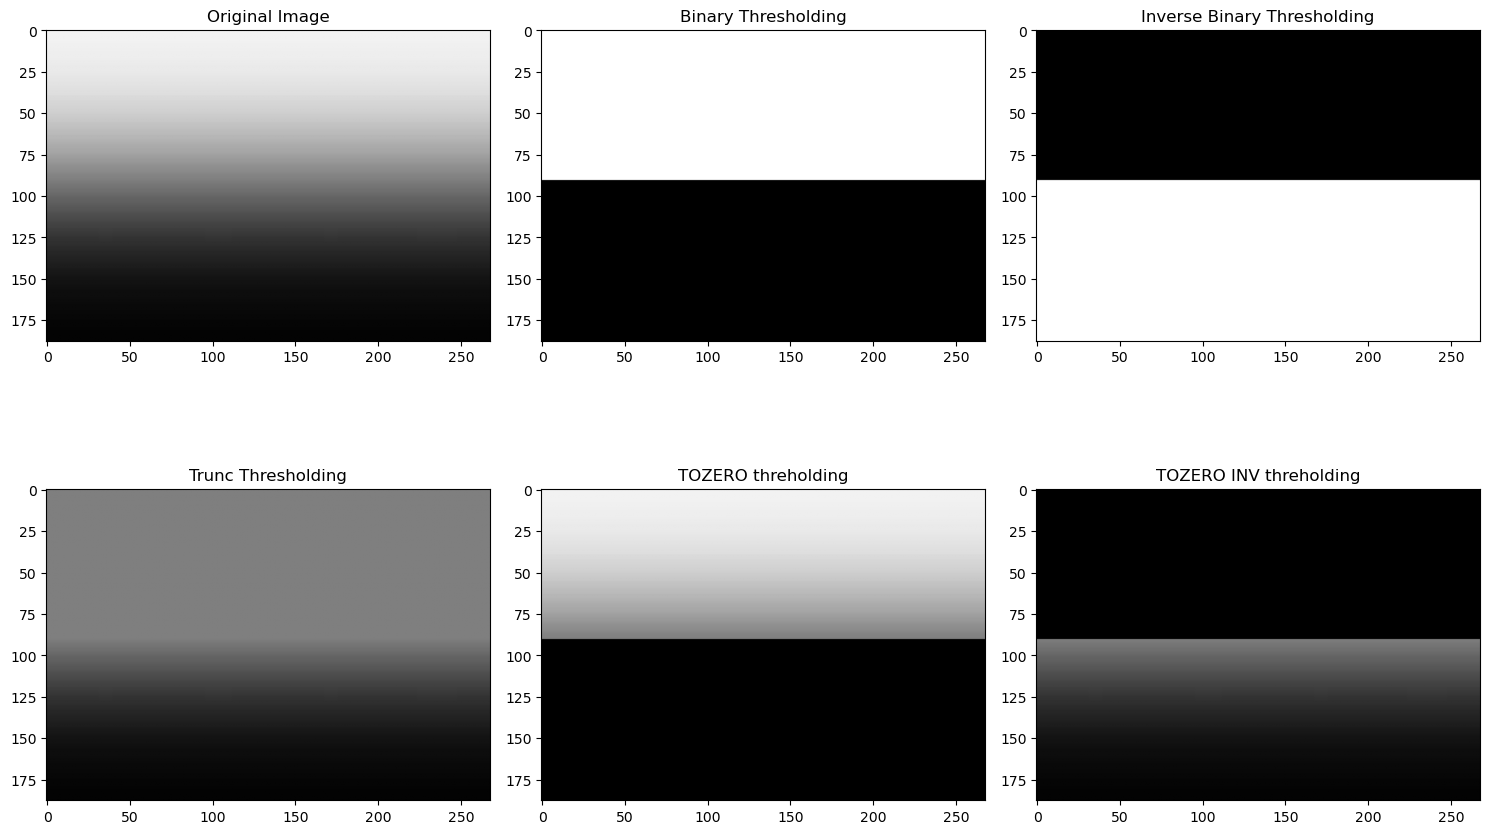

In [1]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread(r"C:\Users\DELL\Desktop\resources\ComputerVision\Computer Vision\Computer Vision Sessions\04s\pic04\gradient.jpg", cv2.IMREAD_GRAYSCALE)

ret1, thresh1 = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
ret2, thresh2 = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY_INV)
ret3, thresh3 = cv2.threshold(image, 127, 255, cv2.THRESH_TRUNC)
ret4, thresh4 = cv2.threshold(image, 127, 255, cv2.THRESH_TOZERO)
ret5, thresh5 = cv2.threshold(image, 127, 255, cv2.THRESH_TOZERO_INV)

def plot_image(images, titles):
    plt.figure(figsize=(15, 10))
    for i, (image, title) in enumerate(zip(images, titles)):
        plt.subplot(2, 3, i + 1); plt.imshow(image, cmap="gray", vmin=0, vmax=255); plt.title(title)
    plt.tight_layout()
    plt.show()

images = [image, thresh1, thresh2, thresh3, thresh4, thresh5]
titles = ["Original Image", "Binary Thresholding", "Inverse Binary Thresholding", "Trunc Thresholding", "TOZERO threholding", "TOZERO INV threholding"]

plot_image(images, titles)

## **2. Otsu's Thresholding**

### **What it is**

Otsu's method **automatically calculates the optimal threshold** instead of you picking one manually. It analyzes the image's histogram and finds the value that best separates it into two classes by maximizing the variance *between* those classes (equivalently, minimizing the variance *within* each class).

Otsu is not a standalone binarization rule — it is only a **threshold-value finder**. It has to be combined with a base type (like `THRESH_BINARY`) that decides what to actually do with the pixels once the optimal T is found.

### **Syntax**

```python
ret, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
```

### **Arguments**

| Argument | Value here | Meaning |
|---|---|---|
| `img` | grayscale image | input |
| `thresh` | `0` | placeholder — **ignored** when Otsu is used |
| `maxval` | `255` | value assigned to pixels above the Otsu-computed threshold |
| `type` | `THRESH_BINARY + THRESH_OTSU` | base rule + "auto-compute the threshold" flag |

### **Use case**

Best for **bimodal images** — histograms with two distinct intensity clusters (e.g. dark text against light paper). Struggles when lighting is uneven across the image, since it still only produces one global threshold.

---
### **Questions I ran into**

**Q: Why do we pass `0` as the threshold value if Otsu calculates it automatically?**

`cv2.threshold()`'s signature always expects a `thresh` argument positionally, whether it's actually used or not (same situation as `max_value` being ignored for `THRESH_TRUNC`). The `THRESH_OTSU` flag tells OpenCV to ignore whatever value you passed and compute the optimal one from the histogram instead — so `0` is just the conventional placeholder. Any number would give an identical result:

```python
# All three produce identical output — the thresh argument is discarded:
cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
cv2.threshold(img, 127, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
cv2.threshold(img, 999, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
```

To see what Otsu actually picked, read the `ret` return value:

```python
ret, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(ret)  # e.g. 138.0 — the computed optimal threshold
```

**Q: Can we use `THRESH_OTSU` alone, without combining it with `THRESH_BINARY`?**

No. `THRESH_OTSU` only *finds* the threshold value — it has no rule for what to do with it once found. `THRESH_BINARY` supplies that rule (pixel > T → maxval, else 0). Neither is complete on its own for this purpose; calling `THRESH_OTSU` alone raises an error.

**Q: Can Otsu be combined with a threshold type other than `THRESH_BINARY`?**

Yes — Otsu just supplies the number T; you can pair it with several base types, and the *same* computed T is used in every case, only the resulting rule changes:

```python
ret, t1 = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
ret, t2 = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
ret, t3 = cv2.threshold(img, 0, 255, cv2.THRESH_TRUNC + cv2.THRESH_OTSU)
ret, t4 = cv2.threshold(img, 0, 255, cv2.THRESH_TOZERO + cv2.THRESH_OTSU)
ret, t5 = cv2.threshold(img, 0, 255, cv2.THRESH_TOZERO_INV + cv2.THRESH_OTSU)
```

- `+ THRESH_BINARY` → clean black/white mask (most common — segmentation, OCR prep)
- `+ THRESH_BINARY_INV` → inverted mask (object darker than background, want it as foreground/white)
- `+ THRESH_TRUNC` → automatically flattens bright regions at the Otsu ceiling
- `+ THRESH_TOZERO` / `+ THRESH_TOZERO_INV` → keeps only bright or only dark regions, with the split point chosen automatically

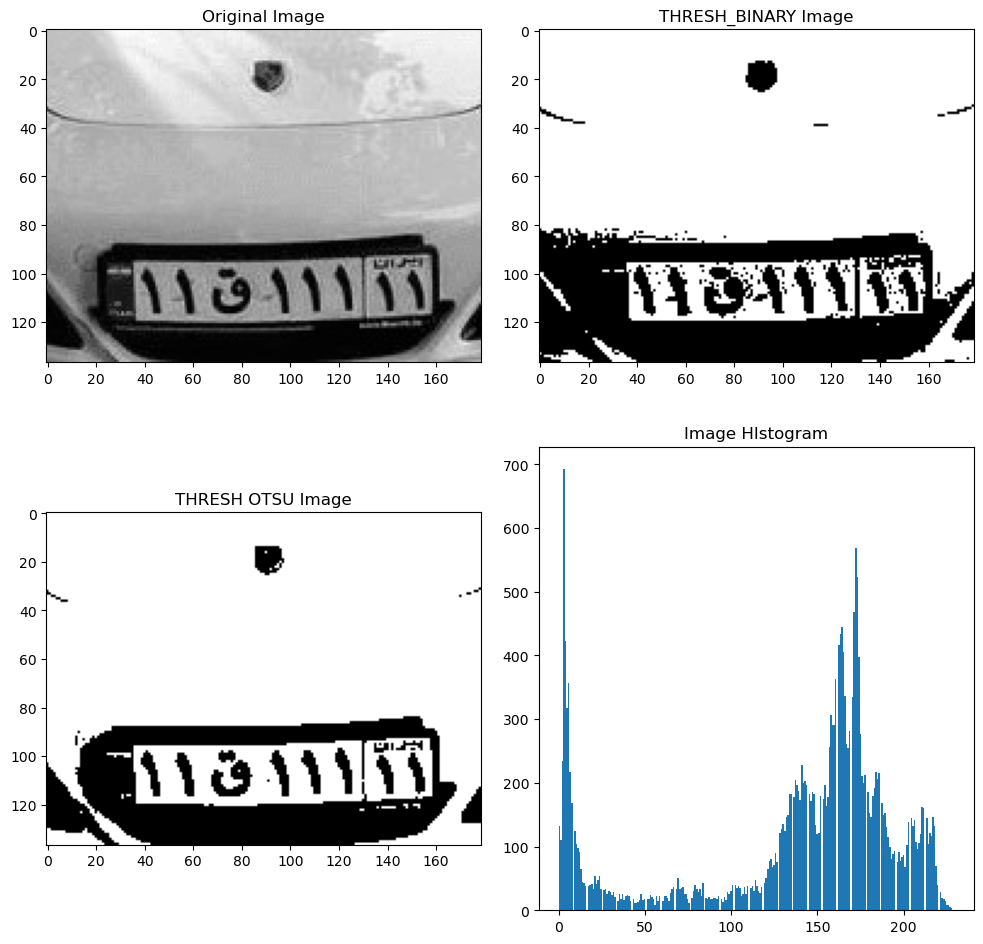

In [2]:
image = cv2.imread(r"C:\Users\DELL\Desktop\resources\ComputerVision\Computer Vision\Computer Vision Sessions\04s\pic04\p2.jpg", cv2.IMREAD_GRAYSCALE)

ret1, binary_thresh = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
ret2, otsu_thresh = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(10, 10))
plt.subplot(221); plt.imshow(image, cmap="gray"); plt.title("Original Image")
plt.subplot(222); plt.imshow(binary_thresh, cmap="gray"); plt.title("THRESH_BINARY Image")
plt.subplot(223); plt.imshow(otsu_thresh, cmap="gray"); plt.title("THRESH OTSU Image")
plt.subplot(224); plt.hist(image.ravel(), 256); plt.title("Image HIstogram")
plt.tight_layout()
plt.show()

## **3. Adaptive Thresholding**

### **What it is**

Instead of one global threshold for the whole image, adaptive thresholding computes a **different threshold for every pixel**, based on a small local neighborhood around it. This is essential when lighting varies across the frame — something a single global value (or even Otsu) cannot handle.

### **Syntax**

```python
adaptive_mean = cv2.adaptiveThreshold(
    img, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY, blockSize=11, C=2
)

adaptive_gaussian = cv2.adaptiveThreshold(
    img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY, blockSize=11, C=2
)
```

### **Arguments**

| Argument | Meaning |
|---|---|
| `img` | grayscale input |
| `maxValue` (`255`) | value assigned to pixels classified as foreground — actually used here |
| `adaptiveMethod` | how to compute the *local* threshold: `ADAPTIVE_THRESH_MEAN_C` or `ADAPTIVE_THRESH_GAUSSIAN_C` |
| `thresholdType` | what to do once the local threshold is found — only `THRESH_BINARY` or `THRESH_BINARY_INV` are supported here |
| `blockSize` | size (in pixels) of the local neighborhood used to compute each pixel's threshold — must be odd and > 1 |
| `C` | constant subtracted from the computed local mean/weighted-mean |

### **Mean vs. Gaussian**

**`ADAPTIVE_THRESH_MEAN_C`** — threshold = simple average of the neighborhood − C. Every pixel contributes equally; faster to compute. Good for smoothly varying lighting and low-noise images.

**`ADAPTIVE_THRESH_GAUSSIAN_C`** — threshold = Gaussian-weighted average of the neighborhood − C, so pixels near the center of the neighborhood count more than pixels near the edge. Slightly more computation, but more robust to noise and produces smoother, less "blocky" masks. This is the more common default in practice, especially for document scans and OCR preprocessing.

### **Use case**

Scanned documents with shadows, photos with uneven lighting, real-world camera captures — anywhere a single global threshold fails because lighting isn't uniform across the frame.

---
### **Questions I ran into**

**Q: What does "uneven lighting" actually mean in practice?**

It means the brightness of the *background itself* isn't constant across the image — one part of the scene is naturally brighter than another, independent of the objects being segmented. Examples: a document photo with a shadow in one corner, a room lit by a single lamp, outdoor lighting with the sun on one side, or lens vignetting.

This breaks global/Otsu thresholding because there's no single cutoff that works everywhere — e.g. the lit-corner background (value ~220) might be brighter than the shadowed-corner foreground (value ~140), so one global T can't separate both regions correctly at once.

**Q: Is adaptive thresholding like Otsu — does it *find* a threshold and then apply it via `THRESH_BINARY`?**

Yes, same structural pattern, with one key difference: Otsu finds **one** global T for the whole image. Adaptive thresholding finds a **different** T for every single pixel, based on that pixel's local neighborhood. The `adaptiveMethod` computes the local threshold; `thresholdType` (BINARY/BINARY_INV) decides what to do with it — which is why only those two binary rules are supported here, since the goal is a fast local binary decision at every pixel.

**Q: Is `blockSize` in pixels?**

Yes. `blockSize=11` means an 11×11 pixel neighborhood centered on each pixel is used to compute that pixel's local threshold. It must be odd (so there's a well-defined center) and greater than 1.

- Smaller `blockSize` → more sensitive to fine local detail, but noisier / can fragment on small texture variation
- Larger `blockSize` → smoother, more stable, but may blur over small features or lose local adaptivity entirely (starts behaving like a global threshold again)

**Q: Why do we subtract `C`?**

Without adjustment, the raw local mean often sits *exactly* on the boundary between background and foreground, making classification unstable — pixels near the mean can flicker between foreground/background due to small noise fluctuations. Subtracting `C` shifts the threshold down, giving foreground pixels more room to clearly qualify, reducing noise/patchiness in the result.

- Higher `C` → threshold drops → more pixels pass as foreground → captures faint detail, but risks noise
- Lower/negative `C` → threshold rises → stricter → cleaner but may lose faint text/edges

`C` is typically tuned empirically (values around 2–10 are common starting points).

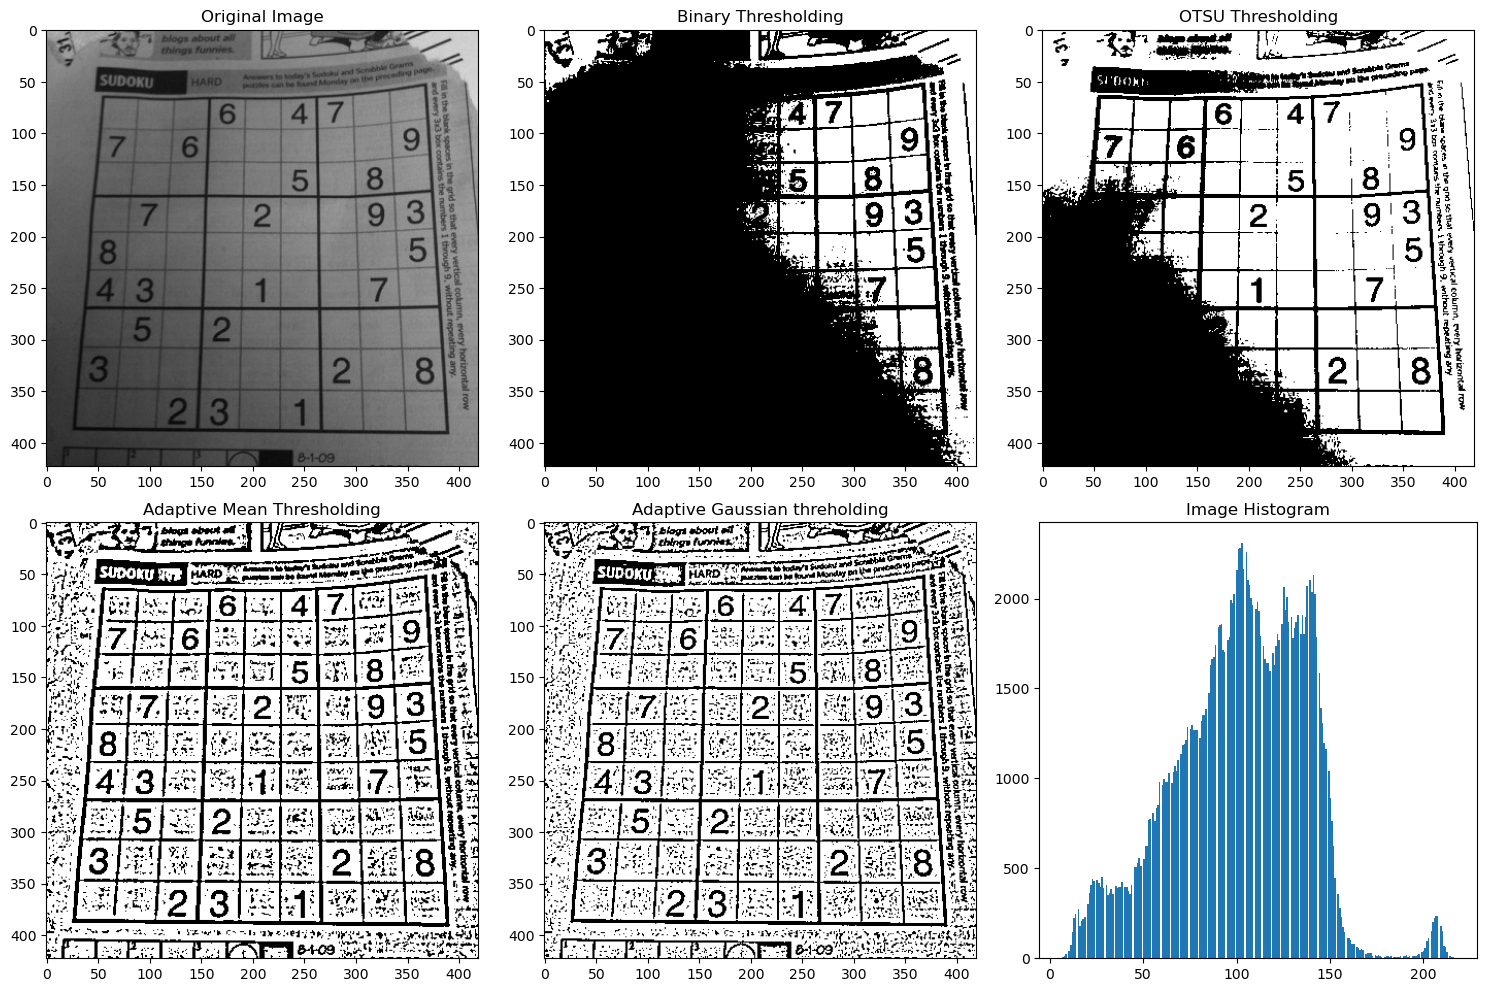

In [5]:
image = cv2.imread(r"C:\Users\DELL\Desktop\resources\ComputerVision\Computer Vision\Computer Vision Sessions\04s\pic04\sudoku.jpg", cv2.IMREAD_GRAYSCALE)

ret1, binary_thresh = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
ret2, otsu_thresh = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
adaptive_mean_thresh = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, blockSize=11, C=2)
adaptive_gaussian_thresh = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, blockSize=11, C=2)

def plot_image(images, titles):
    plt.figure(figsize=(15, 10))
    for i, (image, title) in enumerate(zip(images, titles)):
        plt.subplot(2, 3, i + 1); plt.imshow(image, cmap="gray", vmin=0, vmax=255); plt.title(title)
    

images = [image, binary_thresh, otsu_thresh, adaptive_mean_thresh, adaptive_gaussian_thresh]
titles = ["Original Image", "Binary Thresholding", "OTSU Thresholding", "Adaptive Mean Thresholding", "Adaptive Gaussian threholding"]

plot_image(images, titles)
plt.subplot(236); plt.hist(image.ravel(), 256); plt.title("Image Histogram")
plt.tight_layout()
plt.show()

## **4. Color Thresholding (HSV-based)**

### **What it is**

Instead of thresholding on grayscale *intensity*, this thresholds on **color** — selecting all pixels whose color falls within a specified range. It's typically done in the HSV color space (Hue, Saturation, Value) rather than BGR/RGB, because HSV separates color identity (Hue) from lighting/brightness (Value), making color-based selection far more robust to lighting changes.

### **Syntax**

```python
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
lower = (35, 50, 50)    # lower HSV bound
upper = (85, 255, 255)  # upper HSV bound
mask = cv2.inRange(hsv, lower, upper)
```

### **Arguments**

| Argument | Meaning |
|---|---|
| `hsv` | the image converted to HSV color space |
| `lower` | lower bound (H, S, V) — pixels below this on any channel are excluded |
| `upper` | upper bound (H, S, V) — pixels above this on any channel are excluded |

`cv2.inRange()` returns a mask where pixels **inside** the `[lower, upper]` range become `255`, and everything outside becomes `0`.

### **Use case**

Tracking or isolating a specific colored object — e.g. a green ball, a red traffic sign, colored markers for robotics/AR — where the distinguishing feature is hue rather than brightness.

---
### **Questions I ran into**

**Q: Is the output of `cv2.inRange()` a boolean array, or a grayscale image?**

It's a grayscale-style image, **not** a boolean array:

- Single-channel array, same height/width as the input
- `dtype = uint8` (8-bit unsigned integer), same as a normal grayscale image
- Every pixel is either `0` or `255` — not `True`/`False`

```python
mask = cv2.inRange(hsv, lower, upper)
print(mask.dtype)        # uint8
print(mask.shape)        # (height, width) — single channel
print(np.unique(mask))   # array([0, 255], dtype=uint8)
```

It behaves *like* a boolean mask conceptually (only two states), but is stored as standard `uint8` so it works directly with any OpenCV function expecting a normal image or mask, without needing a type cast:

```python
result = cv2.bitwise_and(img, img, mask=mask)  # works directly, mask is uint8
```

To get an actual boolean array (e.g. for NumPy boolean indexing), convert explicitly:

```python
bool_mask = mask.astype(bool)   # or: mask > 0
```